# EDA — Отклик на кредитный оффер

Разведочный анализ данных для задачи Альфа-Банк × МФТИ.

**Финальный результат: ROC-AUC = 0.76744** (Public LB).

Содержание:
1. Обзор данных (размеры, типы, пропуски)
2. Целевая переменная и дисбаланс
3. Временная структура и дрейф
4. Числовые признаки vs target
5. Категориальные признаки
6. Context-offer группы
7. Корреляционная матрица
8. Train/test drift

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

REPO = Path(".").resolve().parent
train = pd.read_csv(REPO / "data/raw/train_apps.csv")
test = pd.read_csv(REPO / "data/raw/test_apps.csv")

print(f"Train: {train.shape[0]:,} строк × {train.shape[1]} колонок")
print(f"Test:  {test.shape[0]:,} строк × {test.shape[1]} колонок")
print(f"\nКолонки только в train: {set(train.columns) - set(test.columns)}")
train.head()

Train: 145,241 строк × 28 колонок
Test:  36,311 строк × 27 колонок

Колонки только в train: {'target_value'}


,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,...,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,...,NaN,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,...,NaN,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0


## 1. Обзор данных

=== Типы колонок ===
float64    23
object      3
int64       2
Name: count, dtype: int64



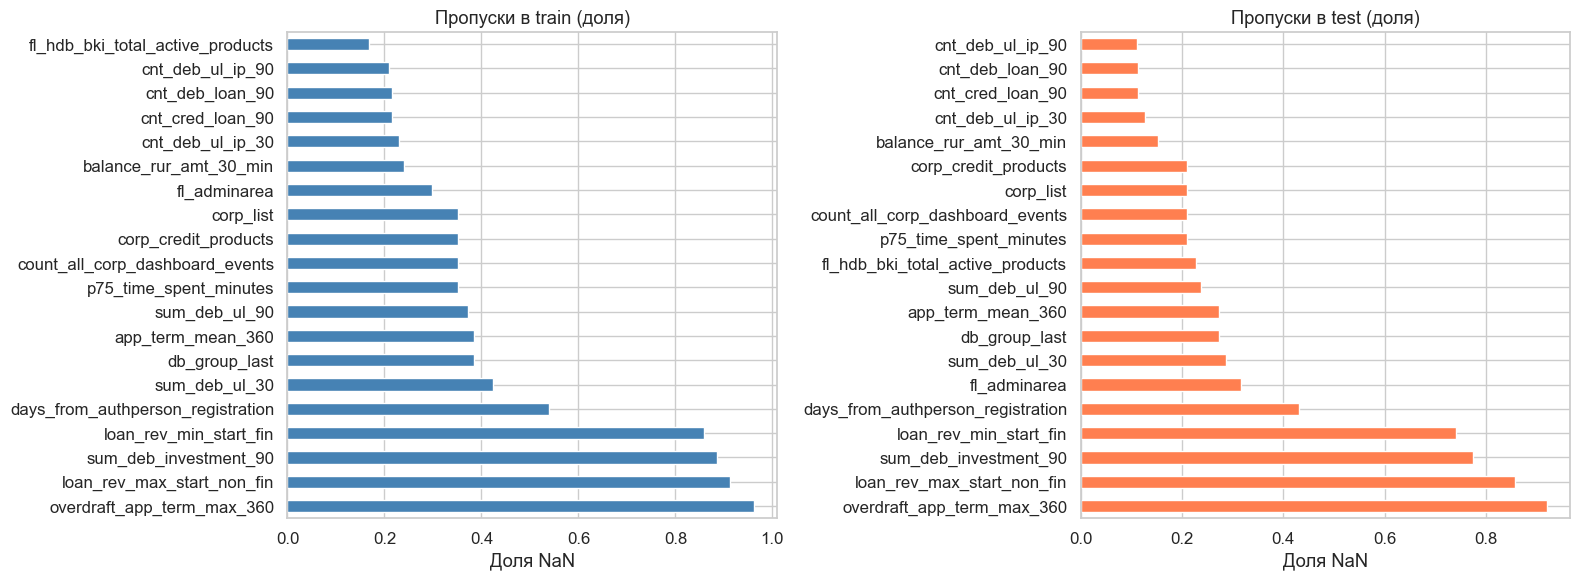


Колонки без пропусков в train: 8
Колонки без пропусков в test:  7


In [2]:
print("=== Типы колонок ===")
print(train.dtypes.value_counts())
print()

# Пропуски
miss_train = train.isnull().mean().sort_values(ascending=False)
miss_test = test.isnull().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
miss_train[miss_train > 0].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Пропуски в train (доля)")
axes[0].set_xlabel("Доля NaN")

miss_test[miss_test > 0].plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Пропуски в test (доля)")
axes[1].set_xlabel("Доля NaN")
plt.tight_layout()
plt.show()

print(f"\nКолонки без пропусков в train: {(miss_train == 0).sum()}")
print(f"Колонки без пропусков в test:  {(miss_test == 0).sum()}")

## 2. Целевая переменная и дисбаланс

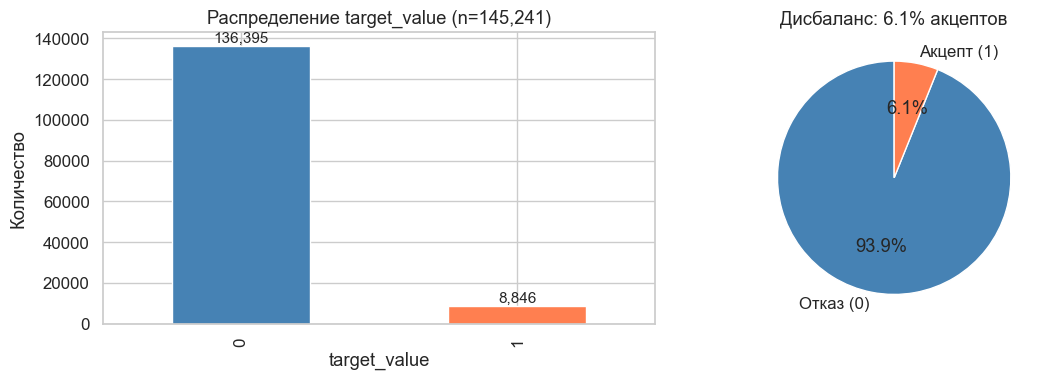

Prevalence: 0.0609 (8,846 из 145,241)


In [3]:
target = "target_value"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train[target].value_counts().sort_index().plot.bar(ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title(f"Распределение target_value (n={len(train):,})")
axes[0].set_xlabel("target_value")
axes[0].set_ylabel("Количество")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2., p.get_height()),
                     ha="center", va="bottom", fontsize=11)

prevalence = train[target].mean()
axes[1].pie([1-prevalence, prevalence], labels=["Отказ (0)", "Акцепт (1)"],
            autopct="%1.1f%%", colors=["steelblue", "coral"], startangle=90)
axes[1].set_title(f"Дисбаланс: {prevalence:.1%} акцептов")

plt.tight_layout()
plt.show()
print(f"Prevalence: {prevalence:.4f} ({train[target].sum():,} из {len(train):,})")

## 3. Временная структура и дрейф

Ключевой инсайт проекта: сильный временной дрейф. `decision_day_num` (ось времени) — главный рычаг решения.

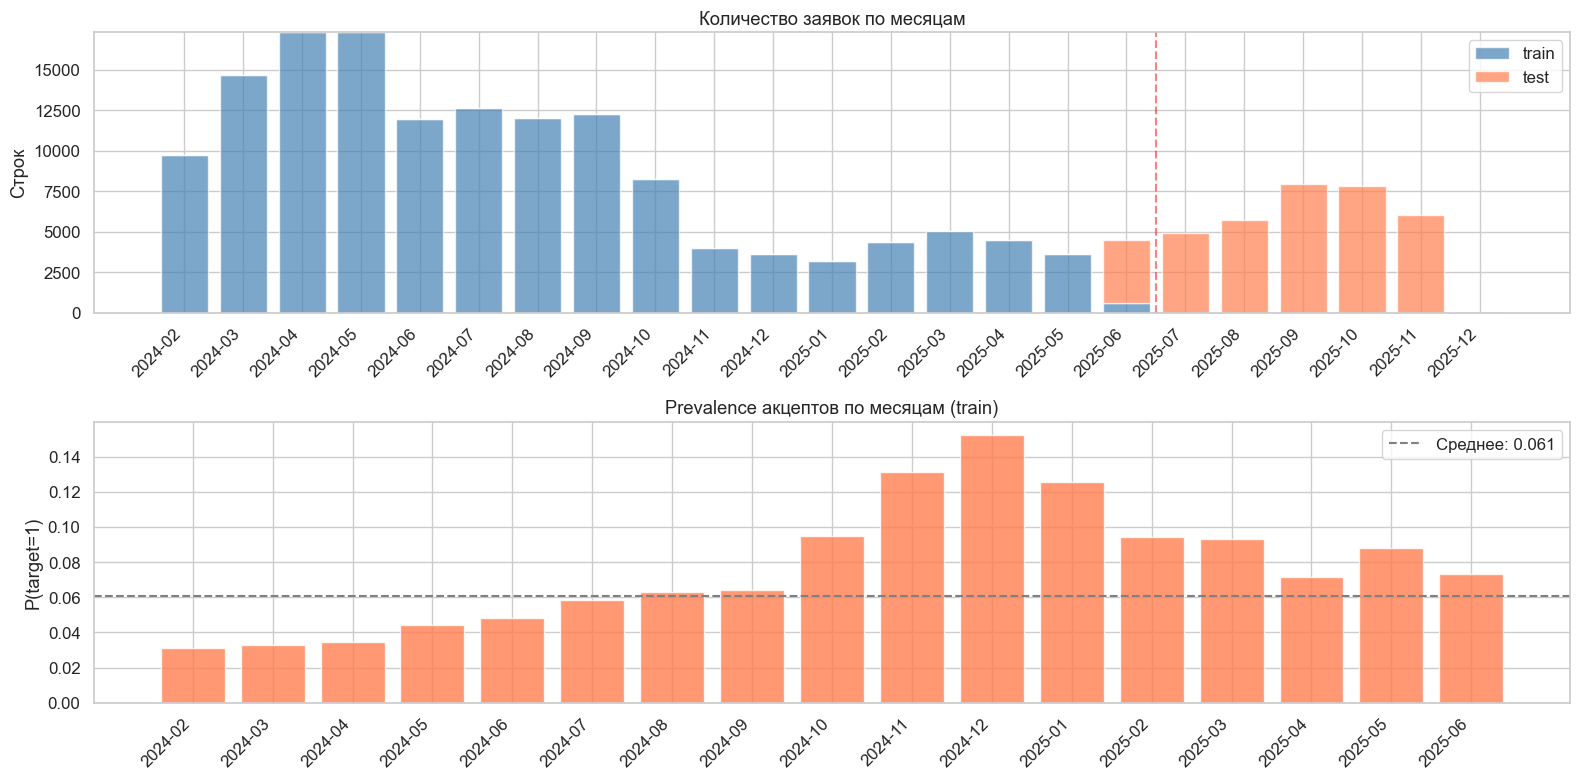


Train: 2024-02-01 .. 2025-06-05
Test:  2025-06-05 .. 2025-12-01

⚠️ Тест полностью ЗА временной границей train
Prevalence мин: 0.0311 (фев'24), макс: 0.1521 (дек'24)
Нестационарность: 4.9×


In [4]:
train["decision_day_dt"] = pd.to_datetime(train["decision_day"])
test["decision_day_dt"] = pd.to_datetime(test["decision_day"])
train["year_month"] = train["decision_day_dt"].dt.to_period("M")
test["year_month"] = test["decision_day_dt"].dt.to_period("M")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# Количество заявок по месяцам (train vs test)
tr_counts = train.groupby("year_month").size()
te_counts = test.groupby("year_month").size()
all_months = sorted(set(tr_counts.index) | set(te_counts.index))
tr_vals = [tr_counts.get(m, 0) for m in all_months]
te_vals = [te_counts.get(m, 0) for m in all_months]
x = range(len(all_months))
axes[0].bar(x, tr_vals, label="train", color="steelblue", alpha=0.7)
axes[0].bar(x, te_vals, bottom=tr_vals, label="test", color="coral", alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(m) for m in all_months], rotation=45, ha="right")
axes[0].set_title("Количество заявок по месяцам")
axes[0].set_ylabel("Строк")
axes[0].legend()
axes[0].axvline(x=len(tr_counts)-0.5, color="red", linestyle="--", alpha=0.5, label="train/test граница")

# Prevalence по месяцам (train only)
monthly = train.groupby("year_month")[target].agg(["mean", "size"]).reset_index()
axes[1].bar(range(len(monthly)), monthly["mean"], color="coral", alpha=0.8)
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels([str(m) for m in monthly["year_month"]], rotation=45, ha="right")
axes[1].set_title("Prevalence акцептов по месяцам (train)")
axes[1].set_ylabel("P(target=1)")
axes[1].axhline(y=prevalence, color="gray", linestyle="--", label=f"Среднее: {prevalence:.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTrain: {train['decision_day_dt'].min().date()} .. {train['decision_day_dt'].max().date()}")
print(f"Test:  {test['decision_day_dt'].min().date()} .. {test['decision_day_dt'].max().date()}")
print(f"\n⚠️ Тест полностью ЗА временной границей train")
print(f"Prevalence мин: {monthly['mean'].min():.4f} (фев'24), макс: {monthly['mean'].max():.4f} (дек'24)")
print(f"Нестационарность: {monthly['mean'].max() / monthly['mean'].min():.1f}×")

## 4. Числовые признаки vs target

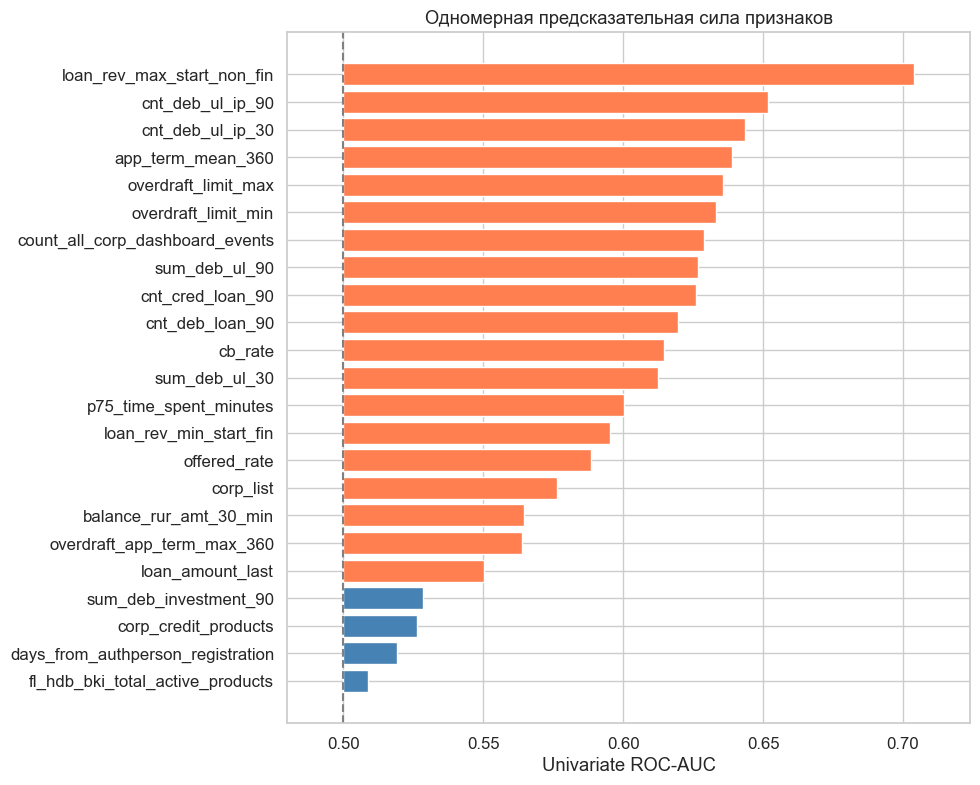

In [5]:
numeric_cols = train.select_dtypes(include=["number"]).columns.drop(target, errors="ignore")
numeric_cols = [c for c in numeric_cols if c != "front_id"]

# ROC-AUC каждого признака vs target (одномерный)
from sklearn.metrics import roc_auc_score

univariate = []
for col in numeric_cols:
    mask = train[col].notna()
    if mask.sum() < 100 or train.loc[mask, target].nunique() < 2:
        continue
    auc = roc_auc_score(train.loc[mask, target], train.loc[mask, col])
    univariate.append({"feature": col, "auc": max(auc, 1 - auc)})

uni_df = pd.DataFrame(univariate).sort_values("auc", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(uni_df) * 0.35)))
colors = ["coral" if a > 0.55 else "steelblue" for a in uni_df["auc"]]
ax.barh(uni_df["feature"], uni_df["auc"] - 0.5, left=0.5, color=colors)
ax.axvline(x=0.5, color="gray", linestyle="--")
ax.set_xlabel("Univariate ROC-AUC")
ax.set_title("Одномерная предсказательная сила признаков")
ax.set_xlim(0.48, max(uni_df["auc"]) + 0.02)
plt.tight_layout()
plt.show()

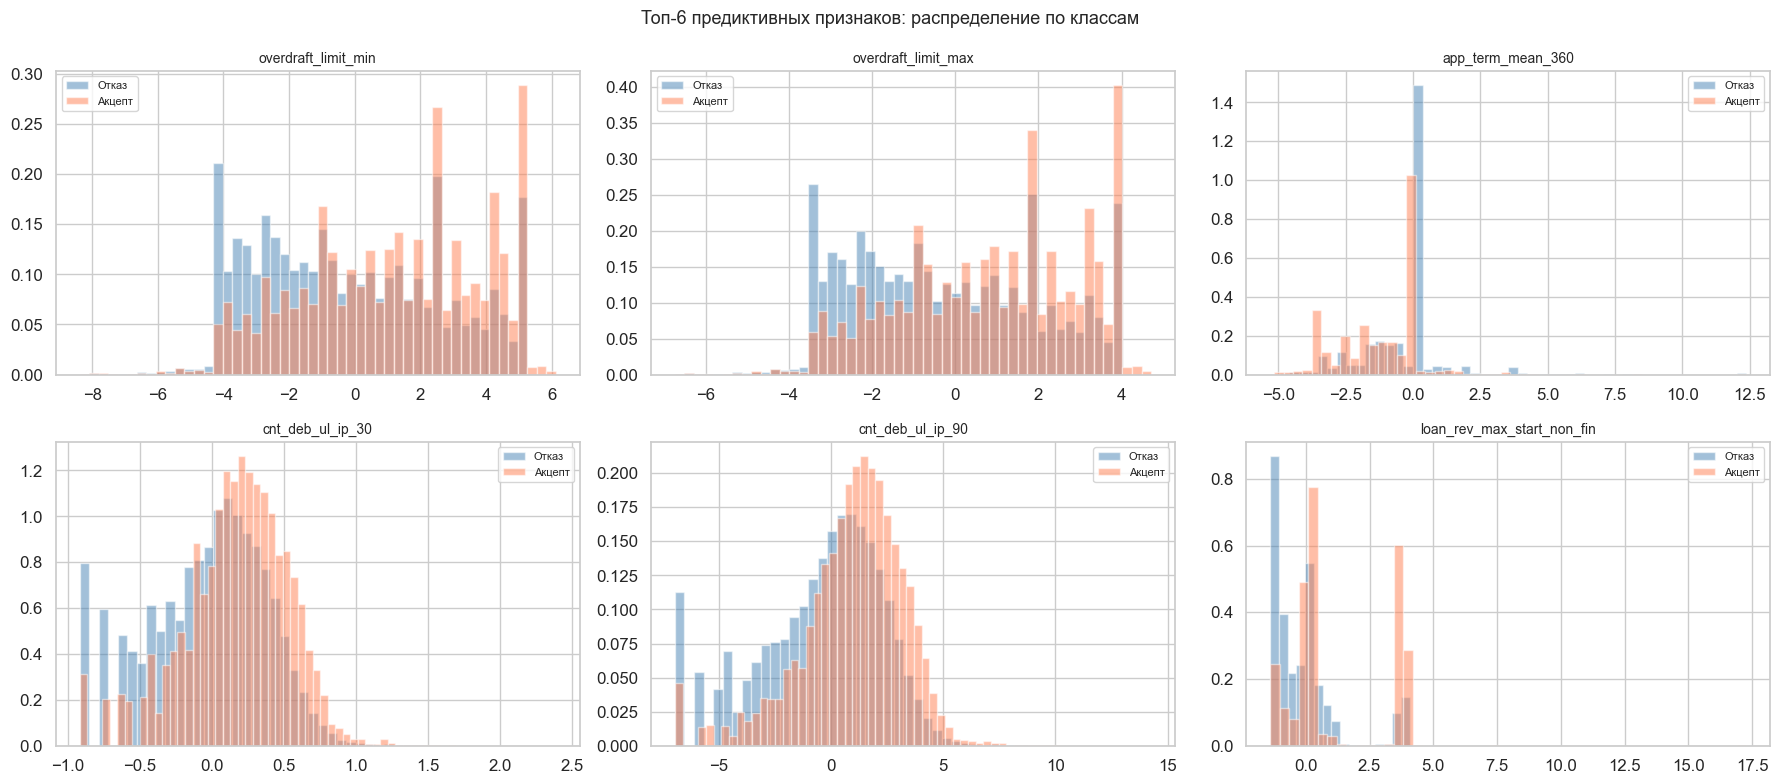

In [6]:
# Топ-6 признаков: распределение по классам
top6 = uni_df.tail(6)["feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.ravel(), top6):
    for val, color, label in [(0, "steelblue", "Отказ"), (1, "coral", "Акцепт")]:
        data = train.loc[train[target] == val, col].dropna()
        ax.hist(data, bins=50, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Топ-6 предиктивных признаков: распределение по классам", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Категориальные признаки

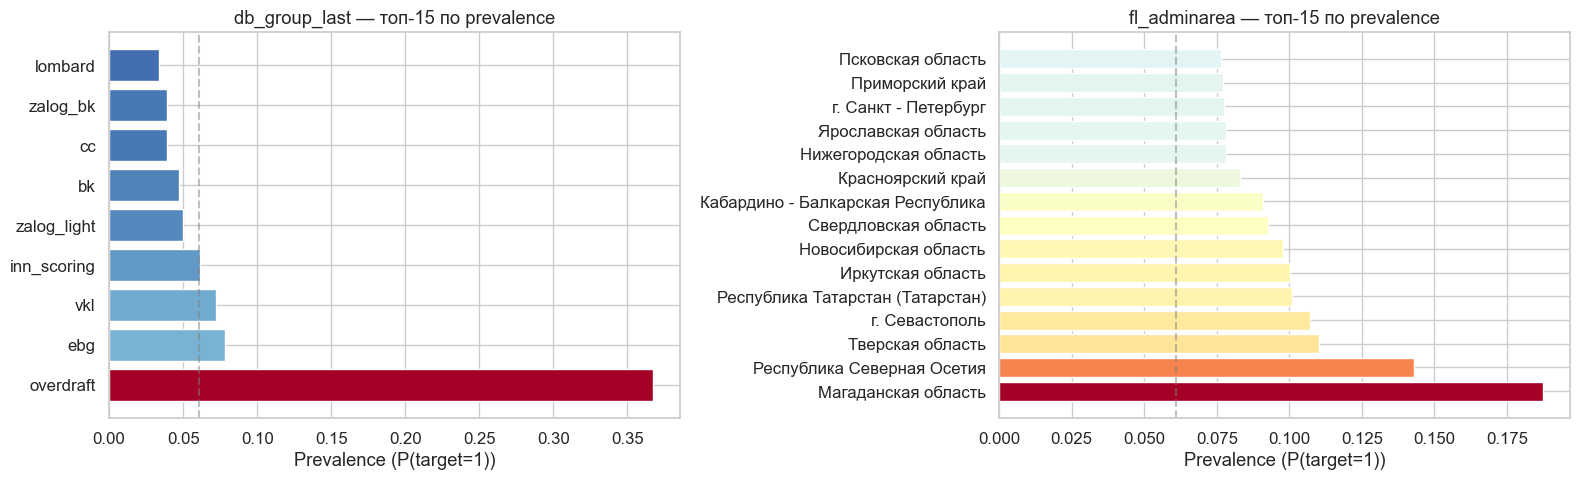

db_group_last: train 9 уник., test 9 уник., пересечение 9, только в test: set()
fl_adminarea: train 83 уник., test 80 уник., пересечение 80, только в test: set()


In [7]:
cat_cols = ["db_group_last", "fl_adminarea"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    ct = train.groupby(col)[target].agg(["mean", "size"]).sort_values("mean", ascending=False).head(15)
    colors = plt.cm.RdYlBu_r(ct["mean"] / ct["mean"].max())
    ax.barh(ct.index.astype(str), ct["mean"], color=colors)
    ax.set_xlabel("Prevalence (P(target=1))")
    ax.set_title(f"{col} — топ-15 по prevalence")
    ax.axvline(x=prevalence, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

for col in cat_cols:
    tr_vals = set(train[col].dropna().unique())
    te_vals = set(test[col].dropna().unique())
    print(f"{col}: train {len(tr_vals)} уник., test {len(te_vals)} уник., "
          f"пересечение {len(tr_vals & te_vals)}, только в test: {te_vals - tr_vals}")

## 6. Context-offer группы

Один запрос может порождать несколько офферов с разными ставками/лимитами.

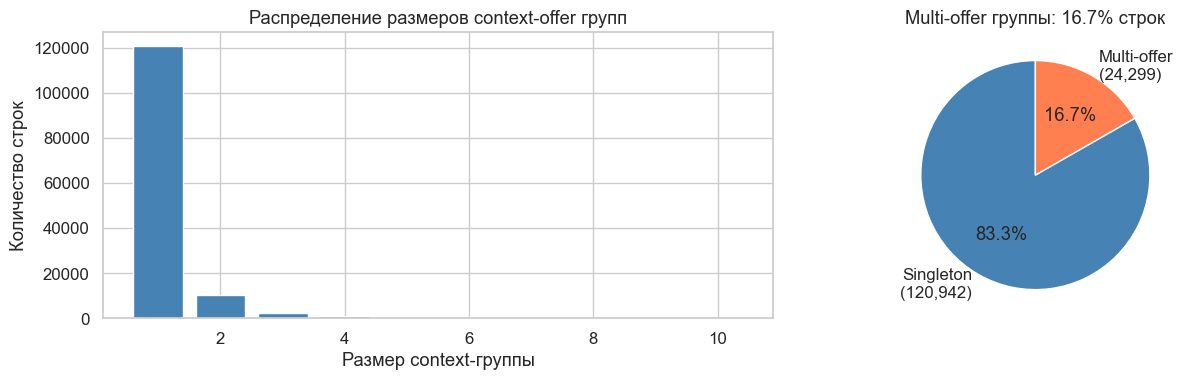

Singleton: 120,942 (83.3%)
Multi-offer: 24,299 (16.7%)
Prevalence singleton: 0.0694
Prevalence multi:     0.0188


In [8]:
offer_cols = ["offered_rate", "overdraft_limit_min", "overdraft_limit_max"]
context_cols = [c for c in train.columns if c not in offer_cols + [target, "front_id", "decision_day",
                                                                    "decision_day_dt", "year_month"]]

ctx_sig = pd.util.hash_pandas_object(train[context_cols].fillna(-999), index=False)
group_sizes = ctx_sig.map(ctx_sig.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

gs = group_sizes.value_counts().sort_index()
axes[0].bar(gs.index[:10], gs.values[:10], color="steelblue")
axes[0].set_xlabel("Размер context-группы")
axes[0].set_ylabel("Количество строк")
axes[0].set_title("Распределение размеров context-offer групп")

multi = group_sizes > 1
labels = [f"Singleton\n({(~multi).sum():,})", f"Multi-offer\n({multi.sum():,})"]
axes[1].pie([(~multi).sum(), multi.sum()], labels=labels, autopct="%1.1f%%",
            colors=["steelblue", "coral"], startangle=90)
axes[1].set_title(f"Multi-offer группы: {multi.mean():.1%} строк")

plt.tight_layout()
plt.show()

print(f"Singleton: {(~multi).sum():,} ({(~multi).mean():.1%})")
print(f"Multi-offer: {multi.sum():,} ({multi.mean():.1%})")
print(f"Prevalence singleton: {train.loc[~multi, target].mean():.4f}")
print(f"Prevalence multi:     {train.loc[multi, target].mean():.4f}")

## 7. Корреляционная матрица

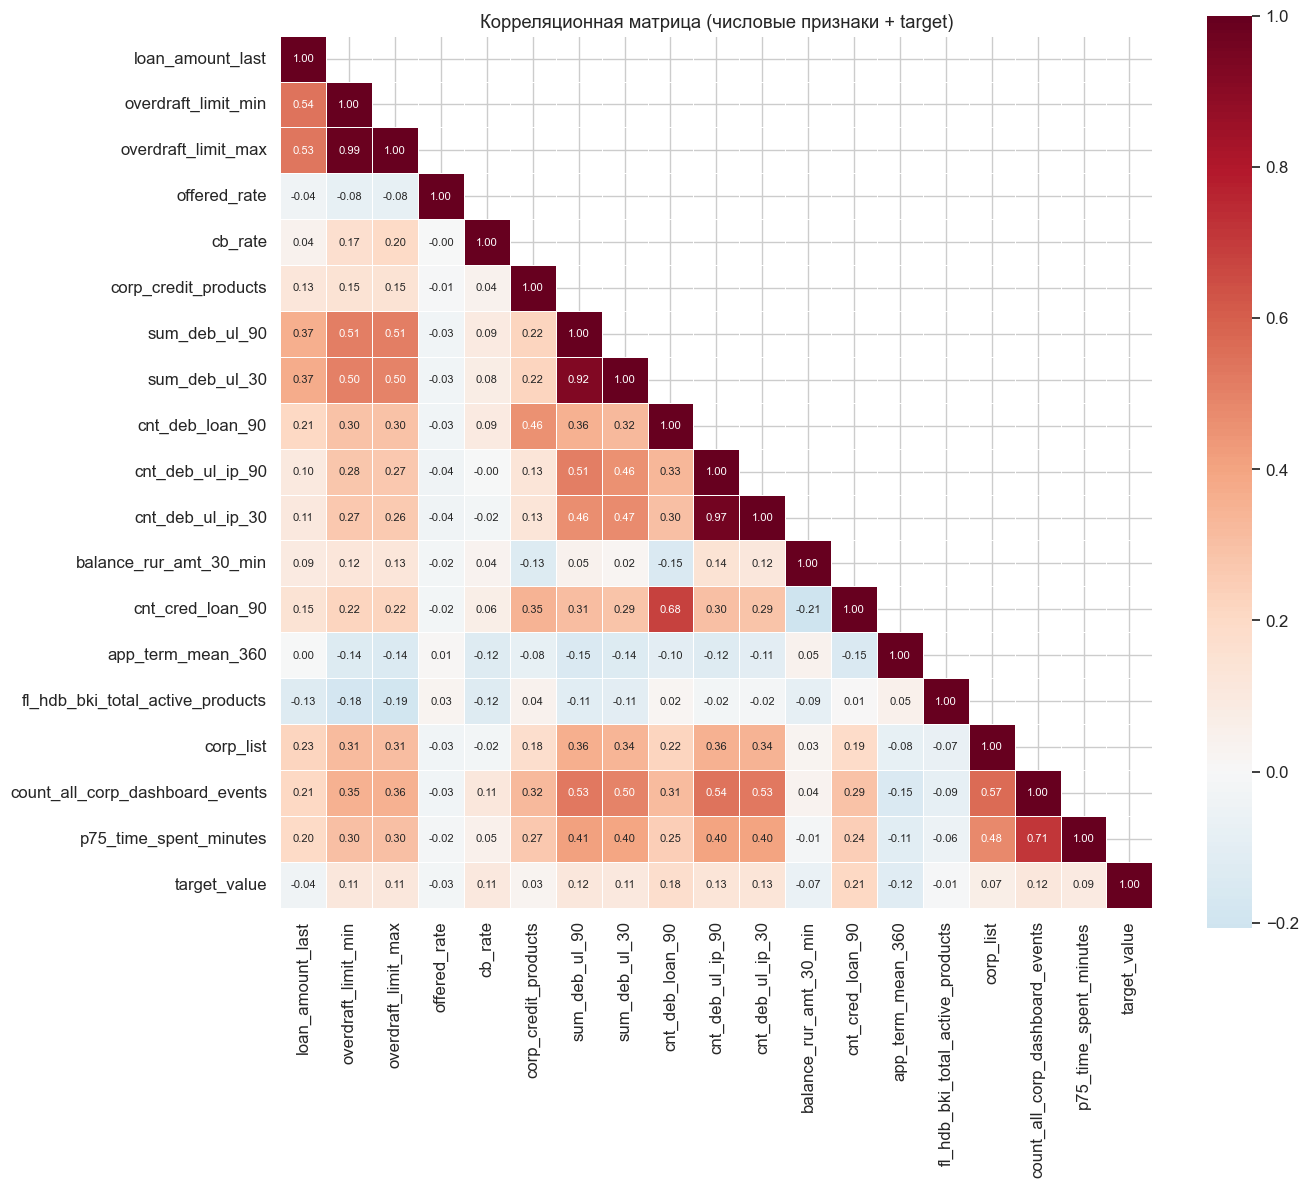

In [9]:
corr_cols = [c for c in numeric_cols if train[c].notna().mean() > 0.5][:20]
corr_cols.append(target)
corr = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Корреляционная матрица (числовые признаки + target)")
plt.tight_layout()
plt.show()

## 8. Train/test drift

Adversarial AUC = 0.7365 (без `decision_day`) — умеренно-сильный дрейф.

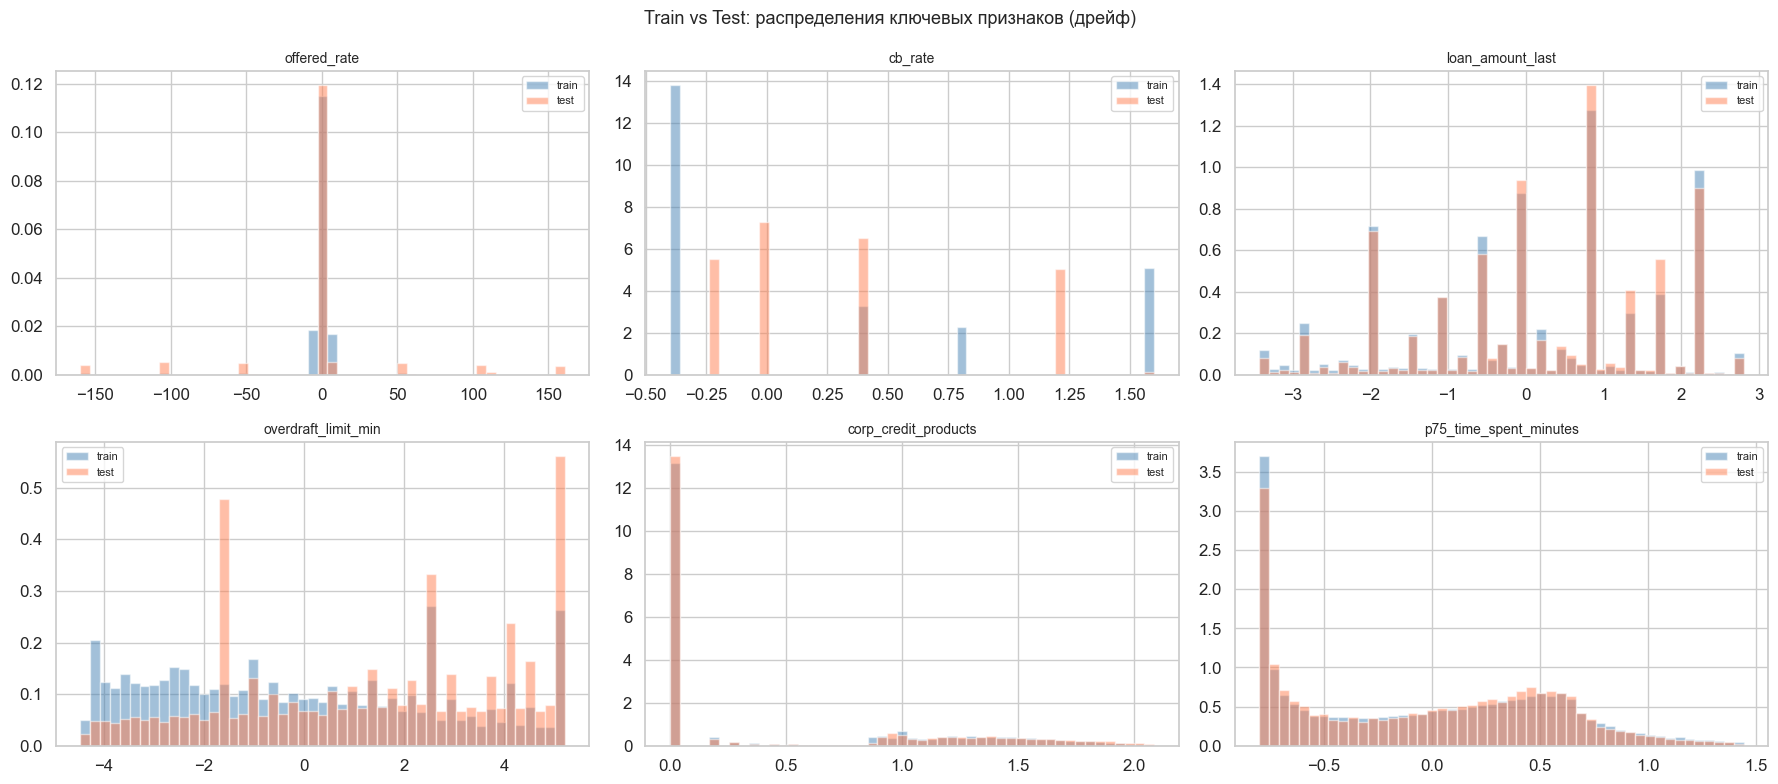

In [10]:
# Сравнение распределений ключевых признаков train vs test
compare_cols = ["offered_rate", "cb_rate", "loan_amount_last", "overdraft_limit_min",
                "corp_credit_products", "p75_time_spent_minutes"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.ravel(), compare_cols):
    tr_data = train[col].dropna()
    te_data = test[col].dropna()
    lo = min(tr_data.quantile(0.01), te_data.quantile(0.01))
    hi = max(tr_data.quantile(0.99), te_data.quantile(0.99))
    bins = np.linspace(lo, hi, 50)
    ax.hist(tr_data, bins=bins, alpha=0.5, color="steelblue", label="train", density=True)
    ax.hist(te_data, bins=bins, alpha=0.5, color="coral", label="test", density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Train vs Test: распределения ключевых признаков (дрейф)", fontsize=13)
plt.tight_layout()
plt.show()

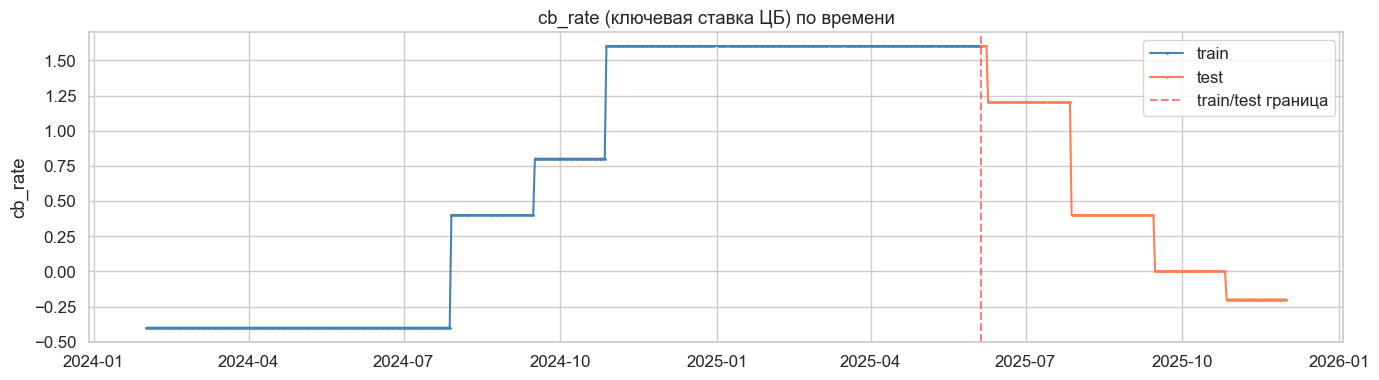

cb_rate train: -0.4007 .. 1.6028
cb_rate test:  -0.2003 .. 1.6028


In [11]:
# cb_rate по времени — ключевой дрейф-фактор
fig, ax = plt.subplots(figsize=(14, 4))

tr_rate = train.groupby("decision_day_dt")["cb_rate"].first().sort_index()
te_rate = test.groupby("decision_day_dt")["cb_rate"].first().sort_index()

ax.plot(tr_rate.index, tr_rate.values, ".-", color="steelblue", label="train", markersize=2)
ax.plot(te_rate.index, te_rate.values, ".-", color="coral", label="test", markersize=2)
ax.axvline(x=train["decision_day_dt"].max(), color="red", linestyle="--", alpha=0.5,
           label="train/test граница")
ax.set_title("cb_rate (ключевая ставка ЦБ) по времени")
ax.set_ylabel("cb_rate")
ax.legend()
plt.tight_layout()
plt.show()

print(f"cb_rate train: {tr_rate.min():.4f} .. {tr_rate.max():.4f}")
print(f"cb_rate test:  {te_rate.min():.4f} .. {te_rate.max():.4f}")

## Выводы

1. **Сильный временной дрейф** — prevalence скачет 5× по месяцам, тест полностью в будущем.
2. **cb_rate нестационарен** — rate-derived фичи (`offered_rate - cb_rate`) имеют temporal drift.
3. **Дисбаланс ~6%** — компенсируется `SqrtBalanced` в CatBoost.
4. **Multi-offer группы = 6%** — не рычаг (acceptance НЕ «выбор 1 из N»).
5. **Главный рычаг — `day_num`** (ось времени), позволяющий модели адаптироваться к позднему режиму.

Подробности — в [SOLUTION.md](../SOLUTION.md).